# <div style="text-align:center; color:Black; font-weight:bold;">Limpieza de base de datos</div>

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:20px">
<b>Limpieza</b><br>
</div>

En este proceso, se tienen 7 etapas: 
- Detección de valores faltantes
- Eliminación de duplicados
- Corrección de errores tipográficos y de codificación
- Normalización de formatos
- Filtrado y tratamiento de valores atípicos (outliers)
- Selección de estrategia de imputación
- Validación posterior a la imputación 


In [1]:
# Uso de Librerías
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:20px">
<b>1. Detección de valores faltantes</b><br>
</div>

In [2]:
# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,4)

# Estilo general
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Crear dataset
df = pd.read_csv("../datos/dataset_depurado.csv", sep=";")

<Figure size 1200x600 with 0 Axes>

In [3]:
# Conteo de valores faltantes ordenado de mayor a menor
faltantes = df.isnull().sum().sort_values(ascending=False)

print("\nConteo de valores faltantes por variable:")
print(faltantes[faltantes > 0])  # Solo muestra variables con al menos un valor faltante


Conteo de valores faltantes por variable:
Series([], dtype: int64)



### <span style="color:Black;"><strong>Interpretación</strong></span>

Como se observa la base datos seleccionada no presenta valores faltantes, por ende no es necesario realizar estrategias de imputación.

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:20px">
<b>2. Eliminación de duplicados</b><br>
</div>

In [4]:
df[df.duplicated(keep=False)]
#df[df.duplicated(subset='price', keep=False)

,price,km,Fuel,Gears,age,Previous_Owners,hp_kW,Inspection_new,Displacement_cc,Weight_kg,cons_comb
2,14640,83450.000000,Diesel,7,3,1,85,0,1598,1135,3.8
5,15090,63668.000000,Diesel,7,3,1,85,0,1598,1135,3.5
15,18700,27000.000000,Diesel,7,3,1,85,0,1598,1275,3.7
19,18500,13406.000000,Diesel,7,1,1,85,0,1598,1135,3.8
81,18500,13406.000000,Diesel,7,1,1,85,0,1598,1135,3.8
...,...,...,...,...,...,...,...,...,...,...,...
15897,41400,10.000000,Diesel,6,0,1,118,0,1997,1758,5.1
15908,39950,1647.362609,Diesel,6,0,1,147,0,1997,1758,5.3
15910,39950,1647.362609,Diesel,6,0,1,147,0,1997,1758,5.3
15913,39700,10.000000,Diesel,6,0,1,147,0,1997,1758,5.3


In [5]:
# 2. Eliminar filas duplicadas
df_sin_duplicados = df.drop_duplicates(keep='first')

# 3. Guardar resultado en un archivo Excel
df_sin_duplicados.to_csv("../datos/dataset_depurado_sin_duplicados.csv", index=False)

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:20px">
<b>3. Corrección de errores tipográficos y de codificación</b><br>
</div>

In [6]:
# cargagamos la nueva base sin valores repetidos
df = pd.read_csv("../datos/dataset_depurado_sin_duplicados.csv", sep=";")

# Identificar columnas categóricas
categoricas = df.select_dtypes(include=['object']).columns

# Revisar si existen diferencias únicamente por capitalización
for col in categoricas:
    valores = df[col].unique()
    if len(set([v.lower() for v in valores])) != len(valores):
        print(f"Posible inconsistencia en columna: {col}")


### <span style="color:Black;"><strong>Interpretación</strong></span>
Se observa que el código no imprime resultado por tanto, la única variable categórica que es Fuel (combustible) no presenta errores tipográficos.

 <div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:20px">
<b>4. Normalización de formatos</b><br>
</div>

### <span style="color:Black;"><strong>Interpretación</strong></span>
No es necesario porque las variables seleccionadas están en la misma unidad de medida o escala.

 <div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:20px">
<b>5. Filtrado y tratamiento de valores atípicos (outliers)</b><br>
</div>

### <span style="color:Black;"><strong>Interpretación</strong></span>
Como se planteó desde el principio, los valores atípicos son normales en la base de datos, puesto que los precios pertenecen a los vehículos de alta gama y el kilometraje alto también es normal debido a vehículos de pruebas que están a la venta en la plataforma.Por el momento se continuan con los valores atípicos y se buscara realizar una transformación

 <div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:20px">
<b>6. Selección de estrategia de imputación</b><br>
</div>

### <span style="color:Black;"><strong>Interpretación</strong></span>
No se realiza imputación.

 <div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:20px">
<b>7. Validación posterior a la imputación</b><br>
</div>

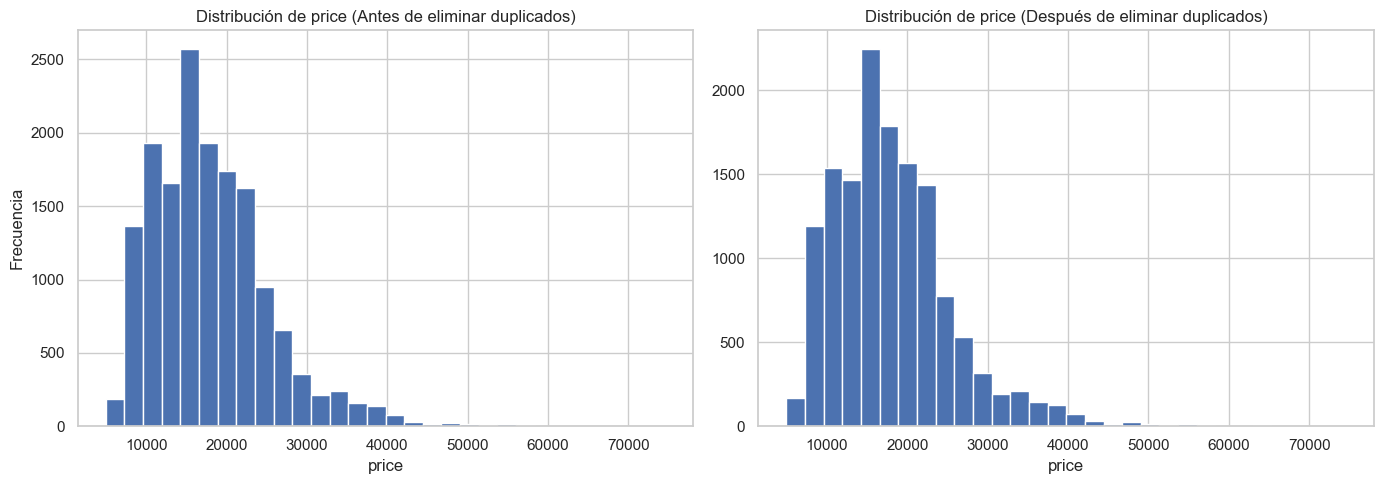

In [7]:
# Cargar datos originales (con duplicados)
df_original = pd.read_csv("../datos/dataset_depurado.csv", sep=";")

# Eliminar duplicados
df_sin_dup = df_original.drop_duplicates()

# Variable a evaluar
variable = "price"   # objeto de estudio precio

plt.figure(figsize=(14,5))

# Histograma antes
plt.subplot(1, 2, 1)
plt.hist(df_original[variable], bins=30)
plt.title(f"Distribución de {variable} (Antes de eliminar duplicados)")
plt.xlabel(variable)
plt.ylabel("Frecuencia")

# Histograma después
plt.subplot(1, 2, 2)
plt.hist(df_sin_dup[variable], bins=30)
plt.title(f"Distribución de {variable} (Después de eliminar duplicados)")
plt.xlabel(variable)

plt.tight_layout()
plt.show()


### <span style="color:Black;"><strong>Interpretación</strong></span>
Se observa que la variable después de la eliminación de duplicados tiene el mismo comportamiento original.